CMP5367

# Objectives
Introduction to Natural Language Processing (NLP)
* Text Preprocessing
* Word Vectorisation
* Word2Vec Exploration and Visualisation



# **Text Preprocessing**

NLP software typically works at the sentence level and
expects a separation of words at the minimum. So, we need some way to split a text
into words and sentences before proceeding further in a processing pipeline. Sometimes,
we need to remove special characters and digits, and sometimes, we don’t care
whether a word is in upper or lowercase and want everything in lowercase. Many
more decisions like this are made while processing text.

We'll start by **tokenization,stemming,lemmatization** :



### **Tokenization**


We can tokenize a sentence into words. We can start with
a simple rule to split text into words based on the presence of punctuation marks.

In this notebook we will demostrate how to perform tokenization, stemming, lemmatization  using libraries like [spacy](https://spacy.io/) and [nltk](https://www.nltk.org/). These are libraries used specifically for NLP task to preprocess text.

We will work with Tweets dataset that is already part of the NLTK library.

We are going to use the Negative and Positive Tweets file which each contains 5000 tweets.

In [1]:
#collapse-hide
# Import libraries and load the data
import numpy as np
import pandas as pd
import re
import nltk
import spacy
import string
import nltk
from nltk.corpus import twitter_samples
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from nltk.stem.snowball import SnowballStemmer
from nltk.stem import WordNetLemmatizer
from bs4 import BeautifulSoup

import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.stem import PorterStemmer,WordNetLemmatizer
from wordcloud import WordCloud
import re
import gensim
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
from sklearn.utils import resample
from sklearn.metrics import accuracy_score,f1_score


pd.options.display.max_columns=None
pd.options.display.max_rows=None
pd.options.display.max_colwidth=None

nltk.download('twitter_samples') # Download the dataset

# We are going to use the Negative and Positive Tweets file which each contains 5000 tweets.
for name in twitter_samples.fileids():
    print(f' - {name}')

[nltk_data] Downloading package twitter_samples to
[nltk_data]     C:\Users\Student\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\twitter_samples.zip.


 - negative_tweets.json
 - positive_tweets.json
 - tweets.20150430-223406.json


In [2]:
#collapse-hide

# Load the negative tweets file and assign label as 0 for negative
negative_tweets = twitter_samples.strings("negative_tweets.json")
df_neg = pd.DataFrame(negative_tweets, columns=['text'])
df_neg['label'] = 0

# Load the positive tweets file and assign label as 1 for positive
positive_tweets = twitter_samples.strings("positive_tweets.json")
df_pos = pd.DataFrame(positive_tweets, columns=['text'])
df_pos['label'] = 1

df = pd.concat([df_pos, df_neg]) # Concatenate both the files
df = df.sample(frac=1).reset_index(drop=True) # Shuffle the data to mix negative and positive tweets

Check the tweets dataset.

In [3]:
print(f'Shape of the whole data is: {df.shape[0]} rows and {df.shape[1]} columns')

Shape of the whole data is: 10000 rows and 2 columns


In [4]:
df.head()

,text,label
0,@sasshoseok did u get called by tp law? :(,0
1,Rain is God's way of telling me that it's time for a nap :-) hehe,1
2,"@LauraAlyceH @weimingkam And by turning up, to be fair! It meant a lot that people came. :)",1
3,I hate this day..... :(,0
4,Bored :(,0


<mark> Note </mark>: Always  check the dataset before performing any text pre-processing steps. It is important because text data can be very noisy eg. dates are written in different formats, present of accented characters, etc. These are stuff we can easily miss if we don't go through the dataset properly.

In [5]:
# check the first tweet

df['text'][0]

'@sasshoseok did u get called by tp law? :('

## Lower Casing

Lowercasing is a common text preprocessing technique. It helps to transform all the text in same case. <br>
Examples 'The', 'the', 'ThE' -> 'the'

This is also useful to find all the duplicates since words in different cases are treated as separate words and becomes difficult for us to remove redundant words in all different case combination.

This may not be helpful when we do tasks Sentiment Analysis (where upper casing refers to anger and so on)

Will create a colum for the preprocessed text

In [6]:
df['text_preprocessed'] = df.text.str.lower()
df.head(2)

,text,label,text_preprocessed
0,@sasshoseok did u get called by tp law? :(,0,@sasshoseok did u get called by tp law? :(
1,Rain is God's way of telling me that it's time for a nap :-) hehe,1,rain is god's way of telling me that it's time for a nap :-) hehe


In [7]:
df['text_preprocessed'][0]

'@sasshoseok did u get called by tp law? :('

## Remove URLS:

URL stands for Uniform Resource Locator. If present in a text, it represents the location of another website.

If we are performing any websites backlink analysis, in that case URL's are useful to keep. Otherwise, they don't provide any information. So we can remove them from our text.

Here we will use a technique called regular expressions. It is a very powerful tool in NLP. You can learn more about Regular Expressions [here](https://learn.microsoft.com/en-us/dotnet/standard/base-types/regular-expression-language-quick-reference).

In [8]:
df.text_preprocessed = df.text_preprocessed.str.replace(r'https?://\S+|www\.\S+', '', regex=True)
df.head()

,text,label,text_preprocessed
0,@sasshoseok did u get called by tp law? :(,0,@sasshoseok did u get called by tp law? :(
1,Rain is God's way of telling me that it's time for a nap :-) hehe,1,rain is god's way of telling me that it's time for a nap :-) hehe
2,"@LauraAlyceH @weimingkam And by turning up, to be fair! It meant a lot that people came. :)",1,"@lauraalyceh @weimingkam and by turning up, to be fair! it meant a lot that people came. :)"
3,I hate this day..... :(,0,i hate this day..... :(
4,Bored :(,0,bored :(


In [9]:
# check first tweet again

df['text_preprocessed'][0]

'@sasshoseok did u get called by tp law? :('

### Emoticons
Emoji's and Emoticons are different. Yes!!<br>
Emoticons are used to express facial expressions using keyboard characters such as letters, numbers, and pucntuation marks. Where emjoi's are small images.

We will convert the emoticons to words as they are important if we want to keep the sentiment in the tweet. Check out how we do this with the following function:

In [10]:
def covert_emoticon(text):


    # change emoticon to text
    text = re.sub(r':\(', 'dislike', text)
    text = re.sub(r': \(\(', 'dislike', text)
    text = re.sub(r':, \(', 'dislike', text)
    text = re.sub(r':\)', 'smile', text)
    text = re.sub(r';\)', 'smile', text)
    text = re.sub(r':\)\)\)', 'smile', text)
    text = re.sub(r':\)\)\)\)\)\)', 'smile', text)
    text = re.sub(r'=\)\)\)\)', 'smile', text)


    tokenizer = text.split()

    return ' '.join([text for text in tokenizer])



**we will apply this function on all the tweets by using hte apply function in Pandas on the text column**

In [11]:
# we will apply this function on all the tweets by using hte apply function in Pandas on the text column
df.text_preprocessed = df["text_preprocessed"].apply(lambda text: covert_emoticon(text))

In [12]:
# check first tweet again
df['text_preprocessed'][0]

'@sasshoseok did u get called by tp law? dislike'

### Punctuations

Punctuations are character other than alphaters and digits. These include [!"#$%&\'()*+,-./:;<=>?@\\^_`{|}~]

It is better remove or convert emoticons before removing the punctuations, since if we do the other we around we might loose the emoticons from the text. Another example, if the text contains $10.50 then we'll remove the .(dot) and the value will loose it's meaning.

In [13]:
PUNCTUATIONS = string.punctuation

def remove_punctuation(text):
    return text.translate(str.maketrans(' ', ' ', PUNCTUATIONS))

**Again the apply function in Pandas to apply the function on the whole text column**

In [14]:
df.text_preprocessed = df["text_preprocessed"].apply(lambda text: remove_punctuation(text))

In [15]:
df.head()

,text,label,text_preprocessed
0,@sasshoseok did u get called by tp law? :(,0,sasshoseok did u get called by tp law dislike
1,Rain is God's way of telling me that it's time for a nap :-) hehe,1,rain is gods way of telling me that its time for a nap hehe
2,"@LauraAlyceH @weimingkam And by turning up, to be fair! It meant a lot that people came. :)",1,lauraalyceh weimingkam and by turning up to be fair it meant a lot that people came smile
3,I hate this day..... :(,0,i hate this day dislike
4,Bored :(,0,bored dislike


### Stopwords

Stopwords are commonly occuring words in any language. Such as, in english these words are 'the', 'a', 'an', & many more. They are in most cases not useful and should be removed. To take the stop word list out, we will use the NLTK list of stop words. We need to download it first:

  

```

import nltk
nltk.download('stopwords') `
```



In [16]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Student\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [17]:
STOPWORDS = set(stopwords.words('english'))

def remove_stopwords(text):
    return ' '.join([word for word in text.split() if word not in STOPWORDS])

In [18]:
# Remove stopwords
df.text_preprocessed = df.text_preprocessed.apply(lambda text: remove_stopwords(text))
df.head()

,text,label,text_preprocessed
0,@sasshoseok did u get called by tp law? :(,0,sasshoseok u get called tp law dislike
1,Rain is God's way of telling me that it's time for a nap :-) hehe,1,rain gods way telling time nap hehe
2,"@LauraAlyceH @weimingkam And by turning up, to be fair! It meant a lot that people came. :)",1,lauraalyceh weimingkam turning fair meant lot people came smile
3,I hate this day..... :(,0,hate day dislike
4,Bored :(,0,bored dislike


### Numbers
We may remove numbers if they are not useful in our analysis. But analysis in the financial domain, numbers are very useful. Again with regular expressions

In [19]:
df.text_preprocessed = df.text_preprocessed.str.replace(r'\d+', '', regex=True)

In [20]:
df.head()

,text,label,text_preprocessed
0,@sasshoseok did u get called by tp law? :(,0,sasshoseok u get called tp law dislike
1,Rain is God's way of telling me that it's time for a nap :-) hehe,1,rain gods way telling time nap hehe
2,"@LauraAlyceH @weimingkam And by turning up, to be fair! It meant a lot that people came. :)",1,lauraalyceh weimingkam turning fair meant lot people came smile
3,I hate this day..... :(,0,hate day dislike
4,Bored :(,0,bored dislike


### Emojis

As more and more people have started using social media emoji's play a very crucial role. Emoji's are used to express emotions that are universally understood.

In some analysis such as sentiment analysis emoji's can be useful. We can convert them to words or create some new features based on them. For some analysis we need to remove them. Find the below code snippet used to remove the emoji's.

In [21]:
#collapse-hide
# Reference: https://gist.github.com/slowkow/7a7f61f495e3dbb7e3d767f97bd7304b

def remove_emoji(text):
    emoji_pattern = re.compile("["
                               u"\U0001F600-\U0001F64F"  # emoticons
                               u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                               u"\U0001F680-\U0001F6FF"  # transport & map symbols
                               u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                               u"\U00002500-\U00002BEF"  # chinese char
                               u"\U00002702-\U000027B0"
                               u"\U00002702-\U000027B0"
                               u"\U000024C2-\U0001F251"
                               u"\U0001f926-\U0001f937"
                               u"\U00010000-\U0010ffff"
                               u"\u2640-\u2642"
                               u"\u2600-\u2B55"
                               u"\u200d"
                               u"\u23cf"
                               u"\u23e9"
                               u"\u231a"
                               u"\ufe0f"  # dingbats
                               u"\u3030"
                               "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r'', text)

In [22]:
text = "game is on 🔥🔥. Hilarious😂"
remove_emoji(text)

'game is on . Hilarious'

In [23]:
# Remove emoji's from text. We use the apply method in pandas
df.text_preprocessed = df.text_preprocessed.apply(lambda x: remove_emoji(x))

In [24]:
df.head()

,text,label,text_preprocessed
0,@sasshoseok did u get called by tp law? :(,0,sasshoseok u get called tp law dislike
1,Rain is God's way of telling me that it's time for a nap :-) hehe,1,rain gods way telling time nap hehe
2,"@LauraAlyceH @weimingkam And by turning up, to be fair! It meant a lot that people came. :)",1,lauraalyceh weimingkam turning fair meant lot people came smile
3,I hate this day..... :(,0,hate day dislike
4,Bored :(,0,bored dislike


### Extra whitespaces

After usually after preprocessing the text there might be extra whitespaces that might be created after transforming, removing various characters. Also, there is a need to remove all the new line, tab characters as well from our text.

In [25]:
def remove_whitespaces(text):
    return " ".join(text.split())

In [26]:
text = "  Whitespaces in the beginning are removed  \t as well \n  as in between  the text   "

clean_text = " ".join(text.split())
clean_text

'Whitespaces in the beginning are removed as well as in between the text'

In [27]:
df.text_preprocessed = df.text_preprocessed.apply(lambda x: remove_whitespaces(x))

### Hashtags and Mentions

We are habituated to use hashtags and mentions in our tweet either to indicate the context or bring attention to an individual. Hashtags can be used to extract features, to see what's trending and in various other applications.

Since, we don't require them we'll remove them.

In [28]:
def remove_tags_mentions(text):
    pattern = re.compile(r'(@\S+|#\S+)')
    return pattern.sub('', text)

In [29]:
text = "live @flippinginja on #younow - jonah and jareddddd"
remove_tags_mentions(text)

'live  on  - jonah and jareddddd'

In [30]:
# Remove hashtags and mentions
df.text_preprocessed = df.text_preprocessed.apply(lambda x: remove_tags_mentions(x))
# check first tweet

df['text_preprocessed'][0]

'sasshoseok u get called tp law dislike'

## Stemming

In stemming we reduce the word to it's base or root form by removing the suffix characters from the word. It is one of the technique to normalize text.

Stemming for root word "like" include:
- "likes"
- "liked"
- "likely"
- "liking"

Stemmed word doesn't always match the words in our dictionary such as:
- console -> consol
- company -> compani
- welcome -> welcom

Due to which stemming is not performed in all nlp tasks.

There are various algorithms used for stemming but the most widely used is PorterStemmer. In this post we have used the PorterStemmer as well.

In [31]:
stemmer = PorterStemmer()

def stem_words(text):
    return ' '.join([stemmer.stem(word) for word in text.split()])

In [32]:
df['text_preprocessed'] = df.text_preprocessed.apply(lambda text: stem_words(text))
df.head()

,text,label,text_preprocessed
0,@sasshoseok did u get called by tp law? :(,0,sasshoseok u get call tp law dislik
1,Rain is God's way of telling me that it's time for a nap :-) hehe,1,rain god way tell time nap hehe
2,"@LauraAlyceH @weimingkam And by turning up, to be fair! It meant a lot that people came. :)",1,lauraalyceh weimingkam turn fair meant lot peopl came smile
3,I hate this day..... :(,0,hate day dislik
4,Bored :(,0,bore dislik


PorterStemmer can be used only for english. If we are working with other than english then we can use SnowballStemmer.

In [33]:
SnowballStemmer.languages

('arabic',
 'danish',
 'dutch',
 'english',
 'finnish',
 'french',
 'german',
 'hungarian',
 'italian',
 'norwegian',
 'porter',
 'portuguese',
 'romanian',
 'russian',
 'spanish',
 'swedish')

## Lemmatization

Lemmatization tried to perform the similar task as that of stemming i.e. trying to reduce the inflection words to it's base form. But lemmatization does it by using a different approach.

Lemmatizations takes into consideration of the morphological analysis of the word. It tries to reduce to words to it's dictionary form which is known as lemma.

For this we need to import Spacy library which has its own lemmatiser



In [39]:
import spacy

# Download spaCy English model if not already present
import sys
!{sys.executable} -m spacy download en_core_web_sm

# Load the spaCy English model
nlp = spacy.load('en_core_web_sm')

# Define a sample text
text = "The quick brown foxes are jumping over the lazy dogs."

# Process the text using spaCy
doc = nlp(text)

# Extract lemmatized tokens
lemmatized_tokens = [token.lemma_ for token in doc]

# Join the lemmatized tokens into a sentence
lemmatized_text = ' '.join(lemmatized_tokens)

# Print the original and lemmatized text
print("Original Text:", text)
print("Lemmatized Text:", lemmatized_text)


     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     -------- ------------------------------- 2.6/12.8 MB 12.6 MB/s eta 0:00:01
     -------------- ------------------------- 4.7/12.8 MB 11.0 MB/s eta 0:00:01
     ------------------------ --------------- 7.9/12.8 MB 12.5 MB/s eta 0:00:01
     --------------------------------- ----- 11.0/12.8 MB 12.5 MB/s eta 0:00:01
     ---------------------------------------- 12.8/12.8 MB 12.4 MB/s  0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
Original Text: The quick brown foxes are jumping over the lazy dogs.
Lemmatized Text: the quick brown fox be jump over the lazy dog .


In [40]:
# function to lemmatise the text with spacy

def text_lemmatize(text):
  doc = nlp(text)
  lemmatized_tokens = [token.lemma_ for token in doc]
  return  ' '.join(lemmatized_tokens)

In [41]:
df['text_preprocessed'] = df.text_preprocessed.apply(lambda text: text_lemmatize(text))
df.head()

,text,label,text_preprocessed
0,@sasshoseok did u get called by tp law? :(,0,sasshoseok u get call tp law dislik
1,Rain is God's way of telling me that it's time for a nap :-) hehe,1,rain god way tell time nap hehe
2,"@LauraAlyceH @weimingkam And by turning up, to be fair! It meant a lot that people came. :)",1,lauraalyceh weimingkam turn fair mean lot peopl come smile
3,I hate this day..... :(,0,hate day dislik
4,Bored :(,0,bear dislik


Difference between Stemming and Lemmatization:

|Stemming | Lemmatization |
| ---- | ---- |
| Fast compared to lemmatization | Slow compared to stemming |
| Reduces the word to it's base form by removing the suffix | Uses lexical knowledge to get the base form of the word |
| Does not always provide meaning or dictionary form of the original word | Resulting words are always meaningful and dictionary words |

# Remember

After all this preprocessing there may be null and empty cells
You have to clean these

In [36]:
df.isnull().sum()

text                 0
label                0
text_preprocessed    0
dtype: int64

## Put all preprocessing steps together in one function

We can create a functiont that will combine all the preprocessing of the tweets together. Remember, each text has its own charactersitics. So the preprocessing and cleaning can differ from text to another (e.g. we may not want to delete punctuations if it indicates a sentiment in sentiment detection task, an all capital word may indicate anger for example)

In [42]:
import nltk
nltk.download('stopwords')

import spacy

# Load the spaCy English model
nlp = spacy.load('en_core_web_sm')

def covert_emoticon(text):


    # change emoticon to text
    text = re.sub(r':\(', 'dislike', text)
    text = re.sub(r': \(\(', 'dislike', text)
    text = re.sub(r':, \(', 'dislike', text)
    text = re.sub(r':\)', 'smile', text)
    text = re.sub(r';\)', 'smile', text)
    text = re.sub(r':\)\)\)', 'smile', text)
    text = re.sub(r':\)\)\)\)\)\)', 'smile', text)
    text = re.sub(r'=\)\)\)\)', 'smile', text)


    tokenizer = text.split()

    return ' '.join([text for text in tokenizer])
PUNCTUATIONS = string.punctuation

def remove_punctuation(text):
    return text.translate(str.maketrans(' ', ' ', PUNCTUATIONS))
STOPWORDS = set(stopwords.words('english'))

def remove_stopwords(text):
    return ' '.join([word for word in text.split() if word not in STOPWORDS])
def remove_emoji(text):
    emoji_pattern = re.compile("["
                               u"\U0001F600-\U0001F64F"  # emoticons
                               u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                               u"\U0001F680-\U0001F6FF"  # transport & map symbols
                               u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                               u"\U00002500-\U00002BEF"  # chinese char
                               u"\U00002702-\U000027B0"
                               u"\U00002702-\U000027B0"
                               u"\U000024C2-\U0001F251"
                               u"\U0001f926-\U0001f937"
                               u"\U00010000-\U0010ffff"
                               u"\u2640-\u2642"
                               u"\u2600-\u2B55"
                               u"\u200d"
                               u"\u23cf"
                               u"\u23e9"
                               u"\u231a"
                               u"\ufe0f"  # dingbats
                               u"\u3030"
                               "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r'', text)
def remove_whitespaces(text):
    return " ".join(text.split())
def remove_tags_mentions(text):
    pattern = re.compile(r'(@\S+|#\S+)')
    return pattern.sub(' ', text)
stemmer = PorterStemmer()

def stem_words(text):
    return ' '.join([stemmer.stem(word) for word in text.split()])

def text_lemmatize(text):
  doc = nlp(text)
  lemmatized_tokens = [token.lemma_ for token in doc]
  return  ' '.join(lemmatized_tokens)

def preprocessing(text):

  text = text.lower()
  text = re.sub(r'https?://\S+|www\.\S+', '', text)
  text = covert_emoticon(text)
  text = remove_punctuation(text)
  text = remove_stopwords(text)
  text = re.sub(r'\d+', '', text)
  text = remove_emoji(text)
  text = remove_whitespaces(text)
  text = remove_tags_mentions(text)
  text = stem_words(text)
  text = text_lemmatize(text)

  return text


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Student\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Test the function on one tweet

In [43]:
df['text'][0]

'@sasshoseok did u get called by tp law? :('

In [44]:
preprocessing(df['text'][0])

'sasshoseok u get call tp law dislik'

Apply the function on the whole tweets column

In [45]:
df['text_preprocessed'] = df['text'].apply(preprocessing)

In [46]:
df.head()

,text,label,text_preprocessed
0,@sasshoseok did u get called by tp law? :(,0,sasshoseok u get call tp law dislik
1,Rain is God's way of telling me that it's time for a nap :-) hehe,1,rain god way tell time nap hehe
2,"@LauraAlyceH @weimingkam And by turning up, to be fair! It meant a lot that people came. :)",1,lauraalyceh weimingkam turn fair mean lot peopl come smile
3,I hate this day..... :(,0,hate day dislik
4,Bored :(,0,bear dislik


In [47]:
#check if you deleted any tweets
df.isnull().sum()

text                 0
label                0
text_preprocessed    0
dtype: int64

# Word Vectorisation

###BOW

Bag of words (BoW) is a classical text representation technique that has been used
commonly in NLP, especially in text classification problems (see Chapter 4). The key
idea behind it is as follows: represent the text under consideration as a bag (collection)
of words while ignoring the order and context. The basic intuition behind it is
that it assumes that the text belonging to a given class in the dataset is characterized
by a unique set of words. If two text pieces have nearly the same words, then they
belong to the same bag (class). Thus, by analyzing the words present in a piece of text,
one can identify the class (bag) it belongs to.

In [48]:
documents = ["Dog bites man.", "Man bites dog.", "Dog eats meat.", "Man eats food."] #Same as the earlier notebook
processed_docs = [doc.lower().replace(".","") for doc in documents]
processed_docs

['dog bites man', 'man bites dog', 'dog eats meat', 'man eats food']

In [49]:
from sklearn.feature_extraction.text import CountVectorizer

#look at the documents list
print("Our corpus: ", processed_docs)

count_vect = CountVectorizer()
#Build a BOW representation for the corpus
bow_rep = count_vect.fit_transform(processed_docs)

#Look at the vocabulary mapping
print("Our vocabulary: ", count_vect.vocabulary_)

#see the BOW rep for first 2 documents
print("BoW representation for 'dog bites man': ", bow_rep[0].toarray())
print("BoW representation for 'man bites dog: ",bow_rep[1].toarray())

#Get the representation using this vocabulary, for a new text
temp = count_vect.transform(["dog and dog are friends"])
print("Bow representation for 'dog and dog are friends':", temp.toarray())


Our corpus:  ['dog bites man', 'man bites dog', 'dog eats meat', 'man eats food']
Our vocabulary:  {'dog': 1, 'bites': 0, 'man': 4, 'eats': 2, 'meat': 5, 'food': 3}
BoW representation for 'dog bites man':  [[1 1 0 0 1 0]]
BoW representation for 'man bites dog:  [[1 1 0 0 1 0]]
Bow representation for 'dog and dog are friends': [[0 2 0 0 0 0]]


## TF-IDF

In all the other approaches we saw so far, all the words in the text are treated equally important. There is no notion of some words in the document being more important than others. TF-IDF addresses this issue. It aims to quantify the importance of a given word relative to other words in the document and in the corpus. It was commonly used representation scheme for information retrieval systems, for extracting relevant documents from a corpus for given text query.

This notebook shows a simple example of how to get the TF-IDF representation of a document using sklearn's TfidfVectorizer.

In [50]:
documents = ["Dog bites man.", "Man bites dog.", "Dog eats meat.", "Man eats food."]
processed_docs = [doc.lower().replace(".","") for doc in documents]
processed_docs

['dog bites man', 'man bites dog', 'dog eats meat', 'man eats food']

In [51]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
bow_rep_tfidf = tfidf.fit_transform(processed_docs)

#IDF for all words in the vocabulary
print("IDF for all words in the vocabulary",tfidf.idf_)
print("-"*10)
#All words in the vocabulary.
print("All words in the vocabulary",tfidf.get_feature_names_out() )
print("-"*10)

#TFIDF representation for all documents in our corpus
print("TFIDF representation for all documents in our corpus\n",bow_rep_tfidf.toarray())
print("-"*10)

temp = tfidf.transform(["dog and man are friends"])
print("Tfidf representation for 'dog and man are friends':\n", temp.toarray())

IDF for all words in the vocabulary [1.51082562 1.22314355 1.51082562 1.91629073 1.22314355 1.91629073]
----------
All words in the vocabulary ['bites' 'dog' 'eats' 'food' 'man' 'meat']
----------
TFIDF representation for all documents in our corpus
 [[0.65782931 0.53256952 0.         0.         0.53256952 0.        ]
 [0.65782931 0.53256952 0.         0.         0.53256952 0.        ]
 [0.         0.44809973 0.55349232 0.         0.         0.70203482]
 [0.         0.         0.55349232 0.70203482 0.44809973 0.        ]]
----------
Tfidf representation for 'dog and man are friends':
 [[0.         0.70710678 0.         0.         0.70710678 0.        ]]


Using a pre-trained word2vec model

Let us take an example of a pre-trained word2vec model, and how we can use it to look for most similar words. We will use the Google News vectors embeddings.
https://drive.google.com/file/d/0B7XkCwpI5KDYNlNUTTlSS21pQmM

A few other pre-trained word embedding models, and details on the means to access them through gensim can be found in:
https://github.com/RaRe-Technologies/gensim-data

In [52]:
import numpy as np

# Get the interactive Tools for Matplotlib
%matplotlib notebook
import matplotlib.pyplot as plt
plt.style.use('ggplot')
from gensim.test.utils import common_texts
from gensim.models import Word2Vec
from sklearn.decomposition import PCA

from gensim.test.utils import datapath, get_tmpfile
from gensim.models import KeyedVectors
from gensim.scripts.glove2word2vec import glove2word2vec

The language model has each word with three hundred dimensions so it takes a while to download

In [53]:
import gensim.downloader as api
wv = api.load('word2vec-google-news-300')

[==================================================] 100.0% 1662.8/1662.8MB downloaded


Check what a vector for the word 'king' looks like. Each number in the vector does  not have a special meaing by itself. But together, the vector carries syntactic and semantic information of the word 'king'

In [54]:
vec_king = wv['king']
vec_king

array([ 1.25976562e-01,  2.97851562e-02,  8.60595703e-03,  1.39648438e-01,
       -2.56347656e-02, -3.61328125e-02,  1.11816406e-01, -1.98242188e-01,
        5.12695312e-02,  3.63281250e-01, -2.42187500e-01, -3.02734375e-01,
       -1.77734375e-01, -2.49023438e-02, -1.67968750e-01, -1.69921875e-01,
        3.46679688e-02,  5.21850586e-03,  4.63867188e-02,  1.28906250e-01,
        1.36718750e-01,  1.12792969e-01,  5.95703125e-02,  1.36718750e-01,
        1.01074219e-01, -1.76757812e-01, -2.51953125e-01,  5.98144531e-02,
        3.41796875e-01, -3.11279297e-02,  1.04492188e-01,  6.17675781e-02,
        1.24511719e-01,  4.00390625e-01, -3.22265625e-01,  8.39843750e-02,
        3.90625000e-02,  5.85937500e-03,  7.03125000e-02,  1.72851562e-01,
        1.38671875e-01, -2.31445312e-01,  2.83203125e-01,  1.42578125e-01,
        3.41796875e-01, -2.39257812e-02, -1.09863281e-01,  3.32031250e-02,
       -5.46875000e-02,  1.53198242e-02, -1.62109375e-01,  1.58203125e-01,
       -2.59765625e-01,  

**What would be similar words to 'Obama'??**

In [55]:
wv.most_similar('obama')

[('mccain', 0.7319012880325317),
 ('hillary', 0.7284600138664246),
 ('obamas', 0.7229632139205933),
 ('george_bush', 0.7205674648284912),
 ('barack_obama', 0.7045838832855225),
 ('palin', 0.7043113708496094),
 ('clinton', 0.6934447884559631),
 ('clintons', 0.6816835403442383),
 ('sarah_palin', 0.6815143823623657),
 ('john_mccain', 0.6800707578659058)]

**Which of these words does not match?? Very powerful model right !!**

In [56]:
print(wv.doesnt_match(['fire', 'water', 'land', 'sea', 'air', 'car']))

car


**Now if you add woman to king what would be the output vector??**

In [57]:
result = wv.most_similar(positive=['woman', 'king'], negative=['man'])
# print("{}: {:.4f}".format(*result[0]))
print('If we add woman + king we get {}: {:.4f}'.format(*result[0]))

If we add woman + king we get queen: 0.7118


**now if you add woman to king and subtract man what would you get?**

In [58]:
result = wv.most_similar(positive=['woman', 'king'], negative=['man'])
print("{}: {:.4f}".format(*result[0]))

queen: 0.7118


In [59]:
def analogy(x1, x2, y1):
    result = wv.most_similar(positive=[y1, x2], negative=[x1])
    return result[0][0]

**Analogy** what is a similar word to these words??

In [60]:
analogy('japan', 'japanese', 'australia')

'canada'

In [61]:
analogy('australia', 'beer', 'france')

'beers'

In [62]:
analogy('obama', 'clinton', 'reagan')

'kerry'

In [63]:
analogy('tall', 'tallest', 'long')

'longest'

In [64]:
analogy('good', 'fantastic', 'bad')

'horrible'

# Visualise the word embedding with dimensionality reduction technique (PCA)

Remember our lecture on PCA. This is one of its utilities

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
%matplotlib inline

def display_google_news_pca(model, words=None, sample=0):
    """
    Displays a PCA scatterplot of word vectors from the word2vec-google-news-300 model.

    Parameters:
    - model: Pre-trained Word2Vec model (Google News).
    - words: List of words to visualize. If None, a random sample will be used.
    - sample: Number of random words to sample if words is None. Ignored if words are provided.
    """
    if words is None:
        if sample > 0:
            words = np.random.choice(model.index_to_key, sample, replace=False)
        else:
            words = model.index_to_key[:100]  # Default: first 100 words

    # Filter words that exist in the model
    words = [word for word in words if word in model]

    if not words:
        print("No valid words found in the model.")
        return

    word_vectors = np.array([model[word] for word in words])

    # Perform PCA to reduce dimensions to 2
    pca = PCA(n_components=2)
    twodim = pca.fit_transform(word_vectors)

    plt.figure(figsize=(10, 10))
    plt.scatter(twodim[:, 0], twodim[:, 1], edgecolors='k', c='skyblue')

    for word, (x, y) in zip(words, twodim):
        plt.text(x + 0.05, y + 0.05, word, fontsize=9)

    plt.title("PCA Scatterplot of Word2Vec Google News Word Vectors")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.grid(True)
    plt.show()


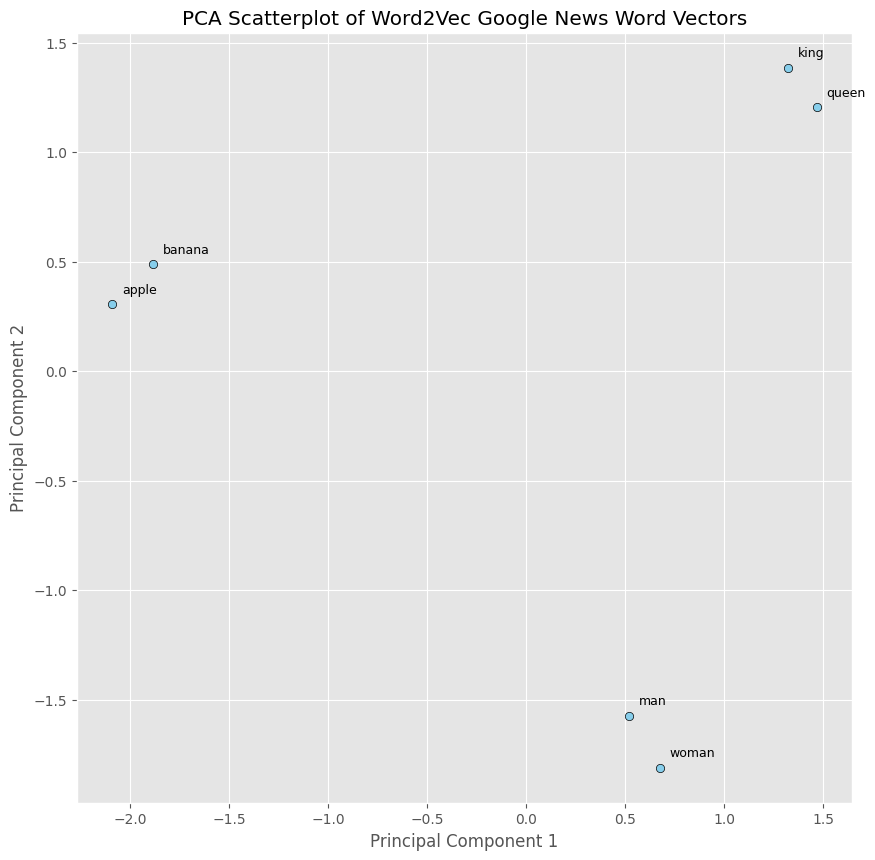

In [66]:
display_google_news_pca(wv, words=['king', 'queen', 'man', 'woman', 'apple', 'banana'])


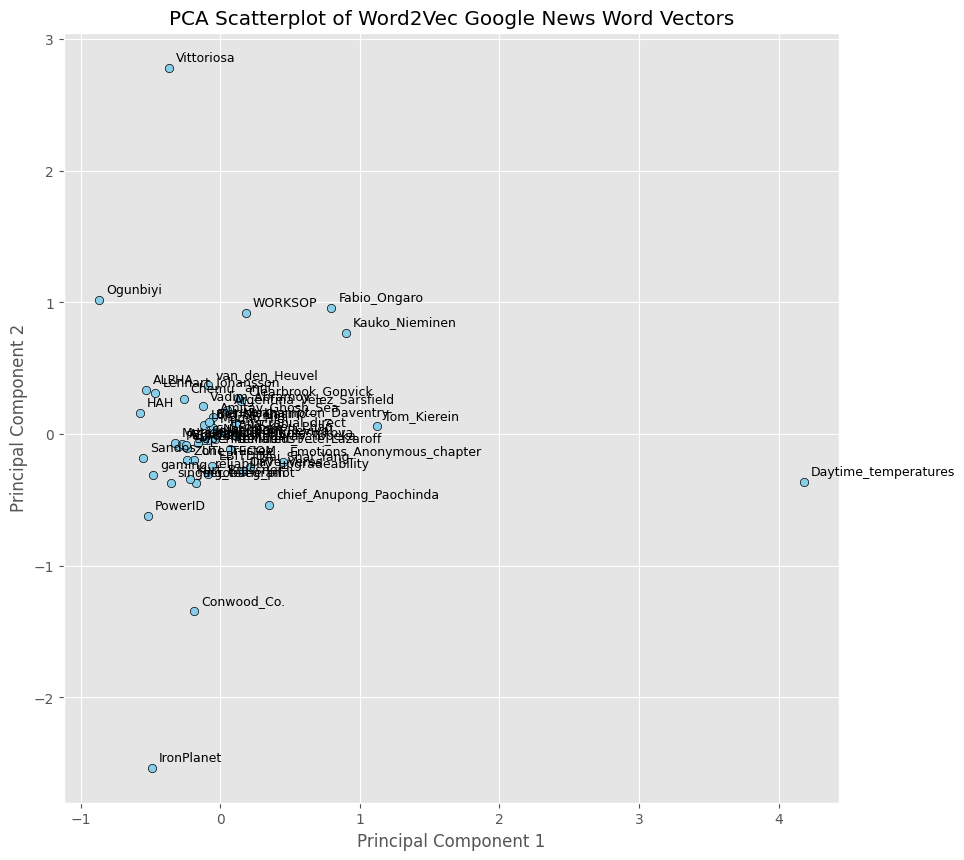

In [67]:
display_google_news_pca(wv, sample=50)


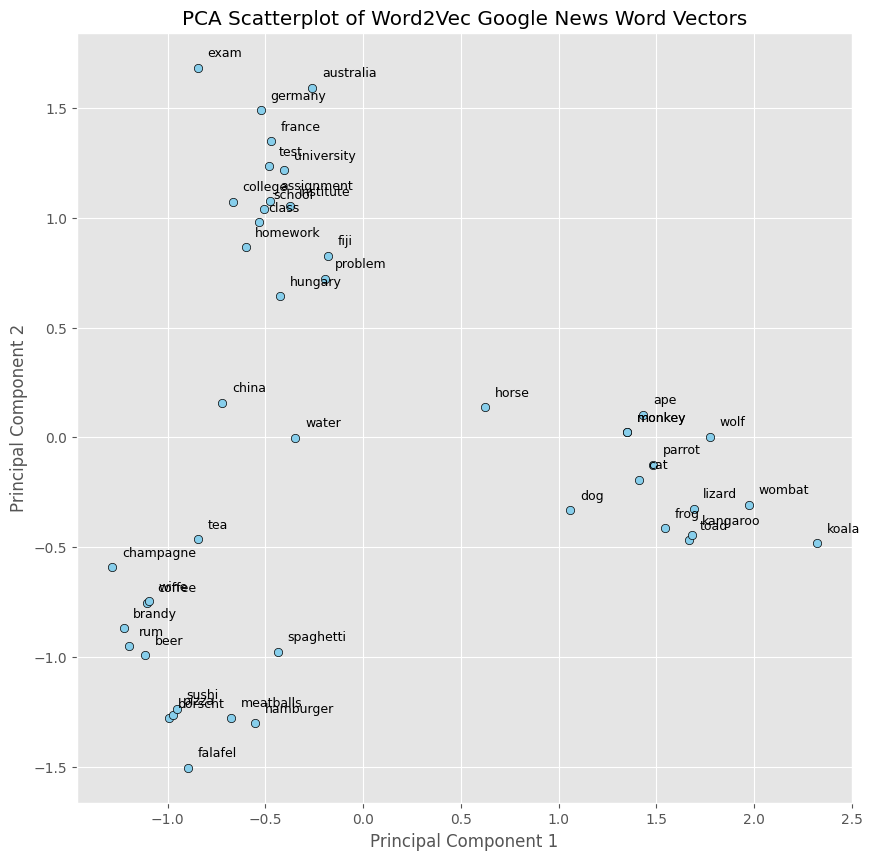

In [68]:
display_google_news_pca(wv,
                        ['coffee', 'tea', 'beer', 'wine', 'brandy', 'rum', 'champagne', 'water',
                         'spaghetti', 'borscht', 'hamburger', 'pizza', 'falafel', 'sushi', 'meatballs',
                         'dog', 'horse', 'cat', 'monkey', 'parrot', 'koala', 'lizard',
                         'frog', 'toad', 'monkey', 'ape', 'kangaroo', 'wombat', 'wolf',
                         'france', 'germany', 'hungary',  'australia', 'fiji', 'china',
                         'homework', 'assignment', 'problem', 'exam', 'test', 'class',
                         'school', 'college', 'university', 'institute'])

## Training on tweets

Let's say we were going to analyze the sentiment of tweets. If we had a list of tweets that were scored positive vs. negative, we could see which words are usually associated with positive scores and which are usually associated with negative scores.

Let's try to train a sentiment detection model on our dataset of tweets. Remember label 0 means that the tweet expresses a negative sentiment and label 1 means the tweet is positive


### is our dataset balanced? and how many rows we have?

In [69]:
df.shape

(10000, 3)

How many **positive** tweets compared to how many **negative** tweets?

In [70]:
df.label.value_counts()

label
0    5000
1    5000
Name: count, dtype: int64

## Train our algorithm


### Vectorize our tweets

We can vectorise our tweets either with Bag-of-Words or TF-IDF frequency. For BOW we use [`CountVectorizer`](https://scikit-learn.org/1.5/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html) from Scikilt learn. For TF-IDF we create a [`TfidfVectorizer`](https://scikit-learn.org/1.5/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html) and use it to vectorize our tweets. Since we don't have all the time in the world, we should probably use `max_features` to only take a selection of words - how about 1000 for now?

In [71]:
df.columns

Index(['text', 'label', 'text_preprocessed'], dtype='object')

This is how we vectorise tweets with BOW

In [72]:
from sklearn.feature_extraction.text import CountVectorizer


count_vect = CountVectorizer(max_features=1000)
vectors = count_vect.fit_transform(df.text_preprocessed)
words_df_bow = pd.DataFrame(vectors.toarray(), columns=count_vect.get_feature_names_out()) # get the words and their frequencies
words_df_bow.head()


,abl,absolut,acc,account,act,activ,actual,ad,add,address,adeccowaytowork,af,afternoon,age,ago,agre,ah,ahh,air,airport,album,alex,all,allow,almost,alon,along,alreadi,alright,also,alway,amaz,amber,amp,ang,anim,annoy,anoth,answer,anymor,anyon,anyth,anyway,apart,app,appar,appreci,aqui,area,around,arriv,art,articl,ask,asleep,ass,august,australia,avail,aw,awak,away,awesom,aww,awww,awwww,babe,babi,back,bad,badli,bae,bag,ball,bam,bank,bare,barsandmelodi,bath,bb,bbi,bc,bday,be,beach,bear,beat,beauti,becom,bed,begin,beli,believ,bestfriend,bet,bhaktisbant,bi,big,bill,bio,birthday,bit,bitch,black,bless,block,blog,blue,bodi,book,bore,box,boy,boyfriend,brain,braindot,bravefrontiergl,break,breakfast,brilliant,bring,bro,brother,btw,bu,buddi,build,burn,busi,buy,bye,cake,call,can,cancel,car,card,care,case,cat,catch,caus,cc,celebr,ceomonth,certain,chanc,chang,channel,chat,check,chee,cheer,chicken,child,chill,chocol,choic,choiceinternationalartist,choo,chri,citi,class,clean,click,close,club,code,coffe,cold,colour,come,comment,commun,complet,comput,concert,confus,congrat,congratul,connect,consid,contact,conver,cool,corn,could,count,countri,coupl,cour,cours,cousin,cover,crave,crazi,cream,creat,cri,cuddl,current,cut,cute,cuti,cuz,cycl,da,dad,damn,danc,dark,date,day,dead,deal,dear,decid,definit,delight,deserv,design,detail,develop,di,die,differ,digit,dinner,disappoint,dislik,dislikedislik,dm,do,dog,door,dot,download,draw,dream,dress,drink,drive,driver,drop,dude,due,ear,earli,early,easi,eat,edit,either,el,email,emilybett,emot,end,english,enjoy,enough,enter,episod,ev,even,event,ever,everi,everyday,everyon,everyth,exactli,exam,excit,expect,experi,extra,eye,fab,face,facebook,facetim,fact,fail,fair,fall,fam,famili,fan,fantast,far,fast,fav,favorit,favourit,fb,fback,featur,feedback,feel,festiv,fever,ff,figur,film,final,find,fine,finger,finish,first,fix,fli,flight,flipkartfashionfriday,folk,follback,follow,followback,followfriday,food,foot,forev,forget,forward,four,freak,free,french,fri,friday,friend,front,fuck,full,fun,funni,futur,game,garden,gay,get,gift,girl,give,giveaway,glad,go,god,goe,gold,good,goodby,goodmorn,goodnight,googl,gorgeou,gosh,great,green,greet,group,grow,gt,gtdislik,gtgt,guess,gut,guy,gym,ha,hack,haha,hahaha,hahahaha,hai,hair,half,hand,hang,happen,happi,hard,harri,hate,have,hay,he,head,headach,hear,heart,hehe,hell,hello,help,here,hey,hi,high,hit,hold,holiday,home,hope,horan,hornykik,horribl,hot,hotel,hour,hous,how,hug,huge,huh,huhu,human,hun,hungri,hurri,hurt,ice,idea,idk,ignor,ill,imag,impastel,import,inact,inde,indiemus,infinit,influenc,info,inform,insid,instagram,instead,interest,internet,invit,iphon,island,issu,it,jame,jaymcgui,jealou,jnlazt,job,join,joke,juli,justi,justinbieb,ka,keep,khan,kid,kik,kikchat,kikgirl,kikhorni,kikm,kikmeboy,kikmenow,kiksext,kill,kind,kinda,kit,know,ko,kunoriforceo,la,ladi,last,late,later,laugh,learn,least,leav,leave,lee,leg,less,let,liam,lie,life,light,like,lil,limit,line,link,list,listen,liter,littl,littlemix,live,ll,lmao,load,lol,london,lone,long,look,lose,lot,loui,love,low,lt,luck,lucki,luke,lunch,luv,mad,madrid,make,man,manag,mani,match,mate,matter,may,mayb,mean,meet,member,memori,mental,mention,mess,messag,mi,michael,middl,might,min,mind,mine,minut,miss,mistak,mm,model,mom,moment,monday,money,month,mood,morn,move,movi,mr,much,mum,music,must,na,name,nd,near,need,never,new,news,next,nice,night,nobodi,nope,normal,nose,not,note,noth,notic,number,offer,offic,offici,oh,ohh,ok,okay,old,omg,one,onlin,oop,open,oppa,opportun,order,origin,other,outfit,outsid,pa,pack,page,pain,pallaviruhail,paper,parent,park,part,parti,pass,past,pay,peac,peopl,perfect,perform,person,phone,photo,physic,pic,pick,pictur,pl,place,plan,play,plea,pleas,pleasur,plz,pm,point,pool,poor,pop,posit,possibl,post,power,pray,present,pretti,price,prob,probabl,problem,product,project,promis,proud,ps,put,queen,question,quick,quit,quot,race,radio,rafaelallmark,rain,rather,rd,read,readi,real,realiz,realli,realliampayn,reason,receiv,recent,record,red,

For this experiment we will use the TF-IDF frequency

In [73]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [74]:
vectorizer = TfidfVectorizer(max_features=1000)
vectors = vectorizer.fit_transform(df.text)
words_df = pd.DataFrame(vectors.toarray(), columns=vectorizer.get_feature_names_out()) # get the words and their frequencies
words_df.head()

,10,100,11,12,13,15,20,2015,24,2nd,30,50,5sos,969horan696,able,about,absolutely,acc,account,actually,add,added,address,adeccowaytowork,af,after,afternoon,again,ago,agree,ah,ahh,ain,album,all,allah,almost,alone,already,also,always,am,amazing,amber,amp,an,and,annoying,another,answer,any,anymore,anyone,anything,anyway,app,apparently,appreciate,appreciated,are,aren,around,arrived,art,article,as,ask,asked,asking,asleep,ass,at,ate,august,available,aw,awake,away,awesome,awful,aww,awww,awwww,babe,baby,back,bad,badly,bae,bag,bam,bank,barsandmelody,bb,bc,bday,be,beach,beat,beautiful,because,become,bed,been,before,being,beli,believe,best,bestfriend,bet,better,bhaktisbanter,big,birthday,bit,bitch,black,blog,blue,body,book,bored,both,bought,box,boy,boys,brain,braindots,breakfast,brilliant,bring,bro,broke,broken,brother,btw,busy,but,buy,by,bye,cake,call,came,can,cannot,cant,car,card,care,case,cat,catch,cause,ceo1month,chance,change,channel,chat,check,cheers,cheese,chocolate,choice,choiceinternationalartist,city,class,click,close,co,code,coffee,cold,come,comes,coming,community,concert,congrats,congratulations,cool,could,couldn,country,course,crazy,cream,cry,crying,cut,cute,da,dad,damn,dark,date,day,days,dead,dear,definitely,deserve,design,details,did,didn,didnt,die,different,dinner,dm,do,does,doesn,dog,doing,don,done,dont,dots,down,dream,dreams,dress,drive,driving,drop,dude,due,during,dying,each,earlier,early,easy,eat,eating,either,else,email,end,ended,english,enjoy,enjoyed,enough,episode,eve,even,ever,every,everyday,everyone,everything,exactly,excited,ext098yq1b,eyes,fab,face,facebook,failed,fair,fall,family,fan,fans,fantastic,far,fast,fav,favorite,favourite,fb,fback,feedback,feel,feeling,feelings,feels,fell,few,ff,final,finally,find,finding,fine,fingers,finish,finished,first,fix,flipkartfashionfriday,follback,follow,followback,followed,follower,followers,followfriday,following,food,for,forever,forget,forgot,forward,found,free,friday,friend,friends,from,front,fuck,fucked,fucking,full,fun,funny,future,game,games,gave,gay,get,gets,getting,gift,girl,girls,give,giveaway,glad,go,god,goes,going,gone,gonna,good,goodbye,goodnight,gorgeous,got,gotta,great,green,group,gt,guess,gutted,guy,guys,gym,ha,had,haha,hahaha,hai,hair,half,happen,happened,happens,happiness,happy,hard,harry,has,hate,have,haven,havent,having,he,head,hear,heard,heart,hehe,hell,hello,help,her,here,hey,hi,high,him,his,hit,hold,holiday,home,hope,hopefully,hoping,hornykik,hot,hour,hours,house,how,http,https,hug,huge,hugs,huhu,hungry,hurt,hurts,ice,id,idea,idk,if,ill,im,impastel,in,indeed,indiemusic,infinite,influencers,info,inside,instagram,instead,interested,interesting,internet,into,invite,iphone,is,isn,issue,it,its,ive,james,jaymcguiness,jealous,jnlazts,job,join,july,just,justi,justinbieber,keep,keeps,kid,kids,kik,kikchat,kikgirl,kikhorny,kikmeboys,kikmenow,kiksexting,killing,kind,kinda,knew,know,ko,la,last,late,later,learn,least,leave,leaving,leeds,left,less,let,lets,life,light,like,liked,likes,lil,line,link,list,listen,listening,literally,little,littlemix,live,ll,lmao,lol,london,long,longer,look,looking,looks,lose,lost,lot,lots,love,loved,lovely,loves,low,lt,luck,lucky,luke,lunch,mad,made,madrid,make,makes,making,man,many,match,may,maybe,me,mean,means,meet,meeting,members,men,mention,message,met,might,mind,mine,mins,miss,missed,missing,model,mom,moment,monday,money,month,months,more,morning,most,move,movie,movies,mr,much,mum,music,must,my,myself,na,name,near,need,needed,needs,never,new,news,next,nice,night,no,nobody,nope,not,nothing,notice,now,number,of,off,offer,office,oh,ohh,ok,okay,old,omg,on,once,one,online,only,open,oppa,opportunities,or,order,original,other,others,our,out,outside,over,own,pa,page,pain,paper,parents,park,part,party,pass,past,pay,people,perfect,person,phone,photo,photos,pic,pick,pics,picture,pictures,place,plan,plans,play,playing,please,pleasure,pls,plz,point,poor,possible,post,pre,pretty,probably,problem,proud,put,queen,question,questions,quick,quite,quote,r

Now this dataset is just the tweets in the original dataset but each tweet now is turned into a vector where each word in our vocabulary (we set it to 1000 words) takes a frequency number based on whether its occurance in the tweet (row in our dataframe).

In [75]:
len(words_df)

10000

Check how the first tweet is turned into a vector of TF-IDF frequency. Note that the vector is very sparse (i.e. it is full of zeros). This is normal as it is expected that the number of words in our dictionary that are mentioned in a tweet will be very limited.

In [76]:
# the first tweet vector

words_df.iloc[0,:]

10                           0.000000
100                          0.000000
11                           0.000000
12                           0.000000
13                           0.000000
15                           0.000000
20                           0.000000
2015                         0.000000
24                           0.000000
2nd                          0.000000
30                           0.000000
50                           0.000000
5sos                         0.000000
969horan696                  0.000000
able                         0.000000
about                        0.000000
absolutely                   0.000000
acc                          0.000000
account                      0.000000
actually                     0.000000
add                          0.000000
added                        0.000000
address                      0.000000
adeccowaytowork              0.000000
af                           0.000000
after                        0.000000
afternoon   

### Setting up our variables

We will try to fit a model on all our dataset to use on our own sentences. We will not create a test set for now. We will use the whole tweets to build a sentiment prediction model that is capable of predicting our own sentences. We need to create two variables: one called `X` and one called `y`.

`X` is all of our **features**, the things we use to predict positive or negative. That's going to be our word vectors.

`y` is all of our **labels**, the positive or negative rating. We'll use the `polarity` column for that.

In [77]:
X = words_df # word vectors
y = df.label # labels 0 and 1 from the original dataset

### Picking an algorithm

What kind of algorithm do we want? Who knows, we don't know anything about machine learning! **Let's just pick ALL OF THEM.**

In [78]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

### Training our algorithms

When we teach our algorithm about what a positive or a negative tweet looks like, this is called **training**. Training can take different amounts of time based on what kind of algorithm you are using.

Check parameters of each model from scikil learn site:

[Logistic regression parameters](https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.LogisticRegression.html)

[Random forest parameters ](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)

[Support Vector Machine parameters](https://scikit-learn.org/dev/modules/generated/sklearn.svm.LinearSVC.html)

[Naive Bayes parameters](https://scikit-learn.org/1.5/modules/generated/sklearn.naive_bayes.MultinomialNB.html)

In [79]:
%%time
# Create and train a logistic regression
logreg = LogisticRegression(C=1e9,  max_iter=1000)
logreg.fit(X, y)

CPU times: total: 10.1 s
Wall time: 1.56 s


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1000000000.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [80]:
%%time
# Create and train a random forest classifier
forest = RandomForestClassifier(n_estimators=50)
forest.fit(X, y)

CPU times: total: 8.33 s
Wall time: 8.71 s


,n_estimators,50
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [81]:
%%time
# Create and train a linear support vector classifier (LinearSVC)
svc = LinearSVC()
svc.fit(X, y)

CPU times: total: 109 ms
Wall time: 108 ms


,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


In [82]:
%%time
# Create and train a multinomial naive bayes classifier (MultinomialNB)
bayes = MultinomialNB()
bayes.fit(X, y)

CPU times: total: 109 ms
Wall time: 79.9 ms


,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


**How long did each take to train?** How much faster were some compared to others?

## Use our models

Now that we've trained our models, **they can try to predict whether some content is positive or negative**.

### Preparing the data

**Add a few more sentences below.** They should be a mix of positive and negative. They can be boring, they can be exciting, they can be short, they can be long.

In [83]:
# Create some test data

pd.set_option("display.max_colwidth", 200)

unknown = pd.DataFrame({'content': [
    "I love love love love this kitten",
    "I hate hate hate hate this keyboard",
    "I'm not sure how I feel about toast",
    "Did you see the baseball game yesterday?",
    "The package was delivered late and the contents were broken",
    "Trashy television shows are some of my favorites",
    "I'm seeing a Kubrick film tomorrow, I hear not so great things about it.",
    "I find chirping birds irritating, but I know I'm not the only one",
]})
unknown

,content
0,I love love love love this kitten
1,I hate hate hate hate this keyboard
2,I'm not sure how I feel about toast
3,Did you see the baseball game yesterday?
4,The package was delivered late and the contents were broken
5,Trashy television shows are some of my favorites
6,"I'm seeing a Kubrick film tomorrow, I hear not so great things about it."
7,"I find chirping birds irritating, but I know I'm not the only one"


First we need to **vectorizer** our sentences into numbers, so the algorithm can understand them.

Our algorithm only knows **certain words.** Run `vectorizer.get_feature_names()` to show you the list of the words it knows.

In [84]:
print(vectorizer.get_feature_names_out())

['10' '100' '11' '12' '13' '15' '20' '2015' '24' '2nd' '30' '50' '5sos'
 '969horan696' 'able' 'about' 'absolutely' 'acc' 'account' 'actually'
 'add' 'added' 'address' 'adeccowaytowork' 'af' 'after' 'afternoon'
 'again' 'ago' 'agree' 'ah' 'ahh' 'ain' 'album' 'all' 'allah' 'almost'
 'alone' 'already' 'also' 'always' 'am' 'amazing' 'amber' 'amp' 'an' 'and'
 'annoying' 'another' 'answer' 'any' 'anymore' 'anyone' 'anything'
 'anyway' 'app' 'apparently' 'appreciate' 'appreciated' 'are' 'aren'
 'around' 'arrived' 'art' 'article' 'as' 'ask' 'asked' 'asking' 'asleep'
 'ass' 'at' 'ate' 'august' 'available' 'aw' 'awake' 'away' 'awesome'
 'awful' 'aww' 'awww' 'awwww' 'babe' 'baby' 'back' 'bad' 'badly' 'bae'
 'bag' 'bam' 'bank' 'barsandmelody' 'bb' 'bc' 'bday' 'be' 'beach' 'beat'
 'beautiful' 'because' 'become' 'bed' 'been' 'before' 'being' 'beli'
 'believe' 'best' 'bestfriend' 'bet' 'better' 'bhaktisbanter' 'big'
 'birthday' 'bit' 'bitch' 'black' 'blog' 'blue' 'body' 'book' 'bored'
 'both' 'bought

Usually when we use the vectorizer, we write code like this:
    
```python
vectors = vectorizer.fit_transform(....)
```

Which both learns all the words **and** counts them. In this case **we already have the list of words we know, we only want to count them.** So instead of `.fit_transform`, we just use `.transform`:

```python
unknown_vectors = vectorizer.transform(unknown.content)
unknown_words_df = ......
```

Finish making your `unknown_words_df` in the cell below.

In [85]:
# Put it through the vectoriser

# transform, not fit_transform, because we already learned all our words
unknown_vectors = vectorizer.transform(unknown.content)
unknown_words_df = pd.DataFrame(unknown_vectors.toarray(), columns=vectorizer.get_feature_names_out())
unknown_words_df.head()

,10,100,11,12,13,15,20,2015,24,2nd,30,50,5sos,969horan696,able,about,absolutely,acc,account,actually,add,added,address,adeccowaytowork,af,after,afternoon,again,ago,agree,ah,ahh,ain,album,all,allah,almost,alone,already,also,always,am,amazing,amber,amp,an,and,annoying,another,answer,any,anymore,anyone,anything,anyway,app,apparently,appreciate,appreciated,are,aren,around,arrived,art,article,as,ask,asked,asking,asleep,ass,at,ate,august,available,aw,awake,away,awesome,awful,aww,awww,awwww,babe,baby,back,bad,badly,bae,bag,bam,bank,barsandmelody,bb,bc,bday,be,beach,beat,beautiful,because,become,bed,been,before,being,beli,believe,best,bestfriend,bet,better,bhaktisbanter,big,birthday,bit,bitch,black,blog,blue,body,book,bored,both,bought,box,boy,boys,brain,braindots,breakfast,brilliant,bring,bro,broke,broken,brother,btw,busy,but,buy,by,bye,cake,call,came,can,cannot,cant,car,card,care,case,cat,catch,cause,ceo1month,chance,change,channel,chat,check,cheers,cheese,chocolate,choice,choiceinternationalartist,city,class,click,close,co,code,coffee,cold,come,comes,coming,community,concert,congrats,congratulations,cool,could,couldn,country,course,crazy,cream,cry,crying,cut,cute,da,dad,damn,dark,date,day,days,dead,dear,definitely,deserve,design,details,did,didn,didnt,die,different,dinner,dm,do,does,doesn,dog,doing,don,done,dont,dots,down,dream,dreams,dress,drive,driving,drop,dude,due,during,dying,each,earlier,early,easy,eat,eating,either,else,email,end,ended,english,enjoy,enjoyed,enough,episode,eve,even,ever,every,everyday,everyone,everything,exactly,excited,ext098yq1b,eyes,fab,face,facebook,failed,fair,fall,family,fan,fans,fantastic,far,fast,fav,favorite,favourite,fb,fback,feedback,feel,feeling,feelings,feels,fell,few,ff,final,finally,find,finding,fine,fingers,finish,finished,first,fix,flipkartfashionfriday,follback,follow,followback,followed,follower,followers,followfriday,following,food,for,forever,forget,forgot,forward,found,free,friday,friend,friends,from,front,fuck,fucked,fucking,full,fun,funny,future,game,games,gave,gay,get,gets,getting,gift,girl,girls,give,giveaway,glad,go,god,goes,going,gone,gonna,good,goodbye,goodnight,gorgeous,got,gotta,great,green,group,gt,guess,gutted,guy,guys,gym,ha,had,haha,hahaha,hai,hair,half,happen,happened,happens,happiness,happy,hard,harry,has,hate,have,haven,havent,having,he,head,hear,heard,heart,hehe,hell,hello,help,her,here,hey,hi,high,him,his,hit,hold,holiday,home,hope,hopefully,hoping,hornykik,hot,hour,hours,house,how,http,https,hug,huge,hugs,huhu,hungry,hurt,hurts,ice,id,idea,idk,if,ill,im,impastel,in,indeed,indiemusic,infinite,influencers,info,inside,instagram,instead,interested,interesting,internet,into,invite,iphone,is,isn,issue,it,its,ive,james,jaymcguiness,jealous,jnlazts,job,join,july,just,justi,justinbieber,keep,keeps,kid,kids,kik,kikchat,kikgirl,kikhorny,kikmeboys,kikmenow,kiksexting,killing,kind,kinda,knew,know,ko,la,last,late,later,learn,least,leave,leaving,leeds,left,less,let,lets,life,light,like,liked,likes,lil,line,link,list,listen,listening,literally,little,littlemix,live,ll,lmao,lol,london,long,longer,look,looking,looks,lose,lost,lot,lots,love,loved,lovely,loves,low,lt,luck,lucky,luke,lunch,mad,made,madrid,make,makes,making,man,many,match,may,maybe,me,mean,means,meet,meeting,members,men,mention,message,met,might,mind,mine,mins,miss,missed,missing,model,mom,moment,monday,money,month,months,more,morning,most,move,movie,movies,mr,much,mum,music,must,my,myself,na,name,near,need,needed,needs,never,new,news,next,nice,night,no,nobody,nope,not,nothing,notice,now,number,of,off,offer,office,oh,ohh,ok,okay,old,omg,on,once,one,online,only,open,oppa,opportunities,or,order,original,other,others,our,out,outside,over,own,pa,page,pain,paper,parents,park,part,party,pass,past,pay,people,perfect,person,phone,photo,photos,pic,pick,pics,picture,pictures,place,plan,plans,play,playing,please,pleasure,pls,plz,point,poor,possible,post,pre,pretty,probably,problem,proud,put,queen,question,questions,quick,quite,quote,r

Confirm `unknown_words_df` is 11 rows and 1,000 columns.

In [86]:
unknown_words_df.shape

(8, 1000)

### Predicting with our models

To make a prediction for each of our sentences, you can use `.predict` with each of our models. For example, it would look like this for linear regression:

```python
unknown['pred_logreg'] = logreg.predict(unknown_words_df)
```

To add the prediction for logistic regression, you'd run similar `.predict` code, which will give you a `0` (negative) or a `1` (positive). A difference between the two is that for logistic regression, you can **also ask for the probability that the sentence is in the `1` category** instead of just simply the category. To do that, you use this code:

```python
unknown['pred_logreg_prob'] = linreg.predict_proba(unknown_words_df)[:,1]
```

**Add new columns for each of the models you trained.** If the model has a `.predict_proba`, add that as a column as well.

* **Tip:** Tab in colab is helpful for knowing whether `.predict_proba` is an option.
* **Tip:** Don't forget the `[:,1]` after `.predict_proba`, it means "give me the probability for category `1` which in our case the positive

In [87]:
df.label.value_counts()

label
0    5000
1    5000
Name: count, dtype: int64

In [88]:
# Predict using all our models.

# Logistic Regression predictions + probabilities
unknown['pred_logreg'] = logreg.predict(unknown_words_df)
unknown['pred_logreg_proba'] = logreg.predict_proba(unknown_words_df)[:,1]

# Random forest predictions + probabilities
unknown['pred_forest'] = forest.predict(unknown_words_df)
unknown['pred_forest_proba'] = forest.predict_proba(unknown_words_df)[:,1]

# SVC predictions
unknown['pred_svc'] = svc.predict(unknown_words_df)

# Bayes predictions + probabilities
unknown['pred_bayes'] = bayes.predict(unknown_words_df)
unknown['pred_bayes_proba'] = bayes.predict_proba(unknown_words_df)[:,1]

In [89]:
unknown

,content,pred_logreg,pred_logreg_proba,pred_forest,pred_forest_proba,pred_svc,pred_bayes,pred_bayes_proba
0,I love love love love this kitten,1,0.717820,1,0.523147,1,1,0.650489
1,I hate hate hate hate this keyboard,0,0.016488,0,0.007744,0,0,0.165379
2,I'm not sure how I feel about toast,0,0.145488,0,0.200000,0,0,0.326945
3,Did you see the baseball game yesterday?,1,0.653982,1,0.520000,1,0,0.474009
4,The package was delivered late and the contents were broken,0,0.051228,1,0.550357,0,0,0.220615
5,Trashy television shows are some of my favorites,1,0.535320,0,0.400000,1,1,0.563208
6,"I'm seeing a Kubrick film tomorrow, I hear not so great things about it.",1,0.846879,1,0.540000,1,1,0.627099
7,"I find chirping birds irritating, but I know I'm not the only one",0,0.056355,0,0.300000,0,0,0.247847


### Questions

* What do the numbers mean? What's the difference between a 0 and a 1? A 0.5? Negative numbers?
* Were there any sentences where the classifiers seemed to disagree about? How do you feel about the amount they disagree?
* What's the difference between using a 0/1 to talk about sentiment compared to 0-1? When might you use one compared to another?
* What's the difference between the linear regression model and the other models we're using? Why might it fit or not fit?
* Between 0-1, what range do you think counts as "negative," "positive" and "neutral"?
* Does the variation in scores reflect the variation you would see among people? Or is it better or worse?

## Testing our models

We can actually see **which model performs the best!** Remember how we trained our models on tweets? We can ask each model about each tweet, and see if it gets the right answer.

In [90]:
df.head()

,text,label,text_preprocessed
0,@sasshoseok did u get called by tp law? :(,0,sasshoseok u get call tp law dislik
1,Rain is God's way of telling me that it's time for a nap :-) hehe,1,rain god way tell time nap hehe
2,"@LauraAlyceH @weimingkam And by turning up, to be fair! It meant a lot that people came. :)",1,lauraalyceh weimingkam turn fair mean lot peopl come smile
3,I hate this day..... :(,0,hate day dislik
4,Bored :(,0,bear dislik


Our original dataframe is a list of many, many tweets. We turned this into `X` - vectorized words - and `y` - whether the tweet is negative or positive.

Before we used `.fit(X, y)` to train on all of our data. Instead, **we can test our models** by doing a test/train split and see if the predictions match the actual labels.

In [91]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y)

In [92]:
%%time

print("Training logistic regression")
logreg.fit(X_train, y_train)

print("Training random forest")
forest.fit(X_train, y_train)

print("Training SVC")
svc.fit(X_train, y_train)

print("Training Naive Bayes")
bayes.fit(X_train, y_train)

Training logistic regression
Training random forest
Training SVC
Training Naive Bayes
CPU times: total: 11.3 s
Wall time: 6.37 s


,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


### Confusion matrices

To see how well they did, we'll use a ["confusion matrix"](https://en.wikipedia.org/wiki/Confusion_matrix) for each one. I think confusion matrices are called that because they are confusing.

In [93]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

#### Logistic Regression

In [94]:
y_true = y_test
y_pred = logreg.predict(X_test)
matrix = confusion_matrix(y_true, y_pred)
print(classification_report(y_test, y_pred))
label_names = pd.Series(['negative', 'positive'])
pd.DataFrame(matrix,
     columns='Predicted ' + label_names,
     index='Is ' + label_names)

              precision    recall  f1-score   support

           0       0.74      0.75      0.75      1263
           1       0.74      0.73      0.74      1237

    accuracy                           0.74      2500
   macro avg       0.74      0.74      0.74      2500
weighted avg       0.74      0.74      0.74      2500



,Predicted negative,Predicted positive
Is negative,953,310
Is positive,332,905


#### Random forest

In [95]:
y_true = y_test
y_pred = forest.predict(X_test)
matrix = confusion_matrix(y_true, y_pred)
print(classification_report(y_test, y_pred))
label_names = pd.Series(['negative', 'positive'])
pd.DataFrame(matrix,
     columns='Predicted ' + label_names,
     index='Is ' + label_names)

              precision    recall  f1-score   support

           0       0.73      0.78      0.75      1263
           1       0.76      0.70      0.73      1237

    accuracy                           0.74      2500
   macro avg       0.74      0.74      0.74      2500
weighted avg       0.74      0.74      0.74      2500



,Predicted negative,Predicted positive
Is negative,988,275
Is positive,369,868


#### SVC

In [96]:
y_true = y_test
y_pred = svc.predict(X_test)
matrix = confusion_matrix(y_true, y_pred)
print(classification_report(y_test, y_pred))
label_names = pd.Series(['negative', 'positive'])
pd.DataFrame(matrix,
     columns='Predicted ' + label_names,
     index='Is ' + label_names)

              precision    recall  f1-score   support

           0       0.75      0.77      0.76      1263
           1       0.76      0.73      0.74      1237

    accuracy                           0.75      2500
   macro avg       0.75      0.75      0.75      2500
weighted avg       0.75      0.75      0.75      2500



,Predicted negative,Predicted positive
Is negative,972,291
Is positive,331,906


#### Multinomial Naive Bayes

In [97]:
y_true = y_test
y_pred = bayes.predict(X_test)
matrix = confusion_matrix(y_true, y_pred)
print(classification_report(y_test, y_pred))
label_names = pd.Series(['negative', 'positive'])
pd.DataFrame(matrix,
     columns='Predicted ' + label_names,
     index='Is ' + label_names)

              precision    recall  f1-score   support

           0       0.74      0.76      0.75      1263
           1       0.75      0.73      0.74      1237

    accuracy                           0.74      2500
   macro avg       0.74      0.74      0.74      2500
weighted avg       0.74      0.74      0.74      2500



,Predicted negative,Predicted positive
Is negative,957,306
Is positive,334,903


### Percentage-based confusion matrices

Those are kind of irritating in that they're just numbers. Let's try percentages instead

#### Logisitic

In [98]:
y_true = y_test
y_pred = logreg.predict(X_test)
matrix = confusion_matrix(y_true, y_pred)
print(classification_report(y_test, y_pred))
label_names = pd.Series(['negative', 'positive'])
pd.DataFrame(matrix,
     columns='Predicted ' + label_names,
     index='Is ' + label_names).div(matrix.sum(axis=1), axis=0)

              precision    recall  f1-score   support

           0       0.74      0.75      0.75      1263
           1       0.74      0.73      0.74      1237

    accuracy                           0.74      2500
   macro avg       0.74      0.74      0.74      2500
weighted avg       0.74      0.74      0.74      2500



,Predicted negative,Predicted positive
Is negative,0.754553,0.245447
Is positive,0.268391,0.731609


#### Logistic regression

In [99]:
y_true = y_test
y_pred = logreg.predict(X_test)
matrix = confusion_matrix(y_true, y_pred)

label_names = pd.Series(['negative', 'positive'])
pd.DataFrame(matrix,
     columns='Predicted ' + label_names,
     index='Is ' + label_names).div(matrix.sum(axis=1), axis=0)

,Predicted negative,Predicted positive
Is negative,0.754553,0.245447
Is positive,0.268391,0.731609


#### Random forest

In [100]:
y_true = y_test
y_pred = forest.predict(X_test)
matrix = confusion_matrix(y_true, y_pred)

label_names = pd.Series(['negative', 'positive'])
pd.DataFrame(matrix,
     columns='Predicted ' + label_names,
     index='Is ' + label_names).div(matrix.sum(axis=1), axis=0)

,Predicted negative,Predicted positive
Is negative,0.782264,0.217736
Is positive,0.298302,0.701698


#### SVC

In [101]:
y_true = y_test
y_pred = svc.predict(X_test)
matrix = confusion_matrix(y_true, y_pred)

label_names = pd.Series(['negative', 'positive'])
pd.DataFrame(matrix,
     columns='Predicted ' + label_names,
     index='Is ' + label_names).div(matrix.sum(axis=1), axis=0)

,Predicted negative,Predicted positive
Is negative,0.769596,0.230404
Is positive,0.267583,0.732417


#### Multinomial Naive Bayes

In [102]:
y_true = y_test
y_pred = bayes.predict(X_test)
matrix = confusion_matrix(y_true, y_pred)

label_names = pd.Series(['negative', 'positive'])
pd.DataFrame(matrix,
     columns='Predicted ' + label_names,
     index='Is ' + label_names).div(matrix.sum(axis=1), axis=0)

,Predicted negative,Predicted positive
Is negative,0.757720,0.242280
Is positive,0.270008,0.729992


## Discussion topics

* Which models performed the best? Were there big differences?
* Do you think it's more important to be sensitive to negativity or positivity? Do we want more positive things incorrectly marked as negative, or more negative things marked as positive?
* They all had very different training times. Which ones offer the best combination of performance and not making you wait around for an hour?
* If you have a decent algorithm that trains more quickly, that could that mean about feature selection or the size of your training set? Why did we use `max_features=` and `df.sample`?
* Is 75% accuracy good?
* Do your feelings change if the performance is described as "incorrect one out of every four times?"
* What would your accuracy be for a random guess?
* How do you feel about sentiment analysis?
* How do you feel about [this piece from the UpShot](https://www.nytimes.com/interactive/2017/02/28/upshot/trump-sounds-different-tone-in-first-address-to-congress.html) that uses [the Emotional Lexicon](http://saifmohammad.com/WebPages/NRC-Emotion-Lexicon.htm)?
* What would you feel comfortable using our sentiment classifier for?

# **Exercise**

1. Clean this content column in the [Trump](https://www.kaggle.com/datasets/austinreese/trump-tweets) dataset.
2. Turn the text into a numerical vector using BOW and TFIDF
3. Train a sentiment classifier model on this dataset and reprot your evaluation and your conclusions

In [104]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("austinreese/trump-tweets")

print("Path to dataset files:", path)

100%|██████████| 6.88M/6.88M [00:00<00:00, 7.57MB/s]

Extracting files...


Path to dataset files: C:\Users\Student\.cache\kagglehub\datasets\austinreese\trump-tweets\versions\3


In [105]:
trump = pd.read_csv(path+'/realdonaldtrump.csv')
trump.head()

,id,link,content,date,retweets,favorites,mentions,hashtags
0,1698308935,https://twitter.com/realDonaldTrump/status/1698308935,Be sure to tune in and watch Donald Trump on Late Night with David Letterman as he presents the Top Ten List tonight!,2009-05-04 13:54:25,510,917,NaN,NaN
1,1701461182,https://twitter.com/realDonaldTrump/status/1701461182,Donald Trump will be appearing on The View tomorrow morning to discuss Celebrity Apprentice and his new book Think Like A Champion!,2009-05-04 20:00:10,34,267,NaN,NaN
2,1737479987,https://twitter.com/realDonaldTrump/status/1737479987,Donald Trump reads Top Ten Financial Tips on Late Show with David Letterman: http://tinyurl.com/ooafwn - Very funny!,2009-05-08 08:38:08,13,19,NaN,NaN
3,1741160716,https://twitter.com/realDonaldTrump/status/1741160716,New Blog Post: Celebrity Apprentice Finale and Lessons Learned Along the Way: http://tinyurl.com/qlux5e,2009-05-08 15:40:15,11,26,NaN,NaN
4,1773561338,https://twitter.com/realDonaldTrump/status/1773561338,"""My persona will never be that of a wallflower - I’d rather build walls than cling to them"" --Donald J. Trump",2009-05-12 09:07:28,1375,1945,NaN,NaN
